# Explore an Example NISAR GCOV Backscatter Time Series

<br>

This notebook introduces the analysis of multi-temporal SAR backscatter image data stacks using the NISAR L2 GCOV data product. GCOV data are a geocoded data product that provides radiometric and terrain corrected backscatter measurements in $\gamma^{0}$ at linear (power) scale.

**This notebook demonstrates:**
1. Accessing and loading of a GCOV times series from S3
1. Subsetting to an area of interest
1. Saving the subset time series as a local Zarr Store
1. Converting between power and sB scales
1. Generating a time series animation and saving it as a gif
1. Calculating a time series of mean backscatter.  

<img src="https://asfopensarlab.github.io/opensarlab-notebook-assets/notebook_images/Nepalclimate.jpeg" width="400" align="right" /> 

This notebook will be access a SAR data stack over Pokhara, Nepal for an introduction to time series processing. The data were acquired by NISAR's L-band sensor and are available from the [Alaska Satellite Facility](https://www.asf.alaska.edu/). 

Nepal is an interesting site for this analysis due to the significant seasonality of precipitation that is characteristic for this region. Nepal is said to have five seasons: spring, summer, monsoon, autumn and winter. Precipitation is low in the winter (November - March) and peaks dramatically in the summer, with top rain rates in July, August, and September (see figure to the right). As SAR is sensitive to changes in soil moisture, these weather patterns have a noticeable impact on the Radar Cross Section ($\sigma$) time series information.

We will analyze the variation of $\gamma^{0}$ values over time and will interpret them in the context of rainfall rates in the imaged area. 

:::{attention} Notes about the time series and this notebook

This notebook accesses data directly from S3 Buckets. This is only possible when run in the AWS `us-west-2` region. 

As of this writing (March 7, 2026), NISAR GCOV data are newly released and the time series is only composed of 5 time steps. As more data become available, the time series will grow, as well as the time it takes to load the data and process them.
:::

<hr>

## Overview
1. [Prerequisites](ts-prereqs)
1. [Search Time Series Data](gcov-ts-search)
1. [Load the Data from S3 with `xarray`](gcov-ts-load)
1. [Save the time series as a local Zarr Store](gcov-ts-save)
1. [Load the time series from the local Zarr Store](gcov-ts-load-from-zarr)
1. [Data Conversion between dB and Power Scales](gcov-ts-convert-scale)
1. [SAR Time Series Animation](gcov-ts-animate)
1. [Calculate the Time Series of Means](gcov-ts-means)
1. [Summary](gcov-ts-summary)
1. [Resources and references](gcov-ts-resources)

<hr>

(ts-prereqs)=
## 1. Prerequisites

| Prerequisite | Importance | Notes |
| --- | --- | --- |
| [The `isce3` software environment for this cookbook](software_environment_docker.ipynb) | Necessary | |
| [How to search and access NISAR data in your {abbr}`AOI (area of interest)`](search_NISAR_GCOV_asf_search.ipynb) | Necessary | If you wish to process data in your AOI instead of the example data |
| [Familiarity with xarray](https://docs.xarray.dev/en/stable/) | Helpful | |
| [Familiarity with matplotlib](https://matplotlib.org/stable/index.html) | Helpful | |

- **Rough Notebook Time Estimate**: 15 minutes (this is based on a 5 image time series and will change as more data become available)
 
<hr>

(gcov-ts-search)= 
## 2. Search Time Series Data

**If you have run this notebook before and already saved a local copy of the time series, skip ahead to section 5.**

### 2a. Search GCOV data and get a list of HTTPS product URLs with `asf_search`

In [1]:
# import os
import asf_search as asf
from datetime import datetime

import warnings
warnings.filterwarnings(
    "ignore",
    message="Parsing dates involving a day of month without a year specified",
)

session = asf.ASFSession()

start_date = datetime(2025, 11, 22)
end_date = datetime(2028, 1, 16)
area_of_interest = "POLYGON((83.8858 28.142,84.3554 28.142,84.3554 28.4825,83.8858 28.4825,83.8858 28.142))" # POINT or POLYGON as WKT (well-known-text)
pattern = r'^(?!.*QA_STATS).*' # used to remove static data files from results

opts=asf.ASFSearchOptions(**{
    "maxResults": 250,
    "intersectsWith": area_of_interest,
    "start": start_date,
    "end": end_date,
    "processingLevel": [
        "GCOV"
    ],
    "dataset": [
        "NISAR"
    ],
    "productionConfiguration": [
        "PR"
    ],
    'session': session,
    "frame": 16,
    "relativeOrbit": 26,
    "flightDirection": "ASCENDING",
})

response = asf.search(opts=opts)
hdf5_urls = response.find_urls(extension='.h5', pattern=pattern, directAccess=False)
print(f"Found {len(hdf5_urls)} GCOV products:")
hdf5_urls

Found 5 GCOV products:


['https://nisar.asf.earthdatacloud.nasa.gov/NISAR/NISAR_L2_GCOV_BETA_V1/NISAR_L2_PR_GCOV_006_026_A_016_4005_DHDH_A_20251123T234739_20251123T234814_X05009_N_F_J_001/NISAR_L2_PR_GCOV_006_026_A_016_4005_DHDH_A_20251123T234739_20251123T234814_X05009_N_F_J_001.h5',
 'https://nisar.asf.earthdatacloud.nasa.gov/NISAR/NISAR_L2_GCOV_BETA_V1/NISAR_L2_PR_GCOV_007_026_A_016_4005_DHDH_A_20251205T234739_20251205T234814_X05009_N_F_J_001/NISAR_L2_PR_GCOV_007_026_A_016_4005_DHDH_A_20251205T234739_20251205T234814_X05009_N_F_J_001.h5',
 'https://nisar.asf.earthdatacloud.nasa.gov/NISAR/NISAR_L2_GCOV_BETA_V1/NISAR_L2_PR_GCOV_008_026_A_016_4005_DHDH_A_20251217T234740_20251217T234815_X05009_N_F_J_001/NISAR_L2_PR_GCOV_008_026_A_016_4005_DHDH_A_20251217T234740_20251217T234815_X05009_N_F_J_001.h5',
 'https://nisar.asf.earthdatacloud.nasa.gov/NISAR/NISAR_L2_GCOV_BETA_V1/NISAR_L2_PR_GCOV_009_026_A_016_4005_DHDH_A_20251229T234740_20251229T234815_X05009_N_F_J_001/NISAR_L2_PR_GCOV_009_026_A_016_4005_DHDH_A_20251229T2

<hr>

(gcov-ts-load)=
## 3. Load the Data from S3 with `xarray`

### 3a. Get NISAR S3 Bucket credentials using your Earthdata Login Bearer Token

:::{figure} ../assets/edl_token.png
:alt: Image of the Earthdata Login Generate Token web page
:width: 75%
:align: left

View or generate a Bearer Token in "Generate Token" tab of the Profile page in your Earthdata Login account: https://urs.earthdata.nasa.gov/profile
:::


In [3]:
from getpass import getpass
import json
import s3fs
import urllib

token = getpass("Enter your EDL Bearer Token")
bucket = "sds-n-cumulus-prod-nisar-products"
prefix = "NISAR_L2_GCOV_BETA_V1"

event = {
    "CredentialsEndpoint": "https://nisar.asf.earthdatacloud.nasa.gov/s3credentials",
    "BearerToken": token,
    "Bucket": bucket,
    "Prefix": prefix,
}

# Get temporary download credentials
tea_url = event["CredentialsEndpoint"]
bearer_token = event["BearerToken"]
req = urllib.request.Request(
    url=tea_url,
    headers={"Authorization": f"Bearer {bearer_token}"}
)
with urllib.request.urlopen(req) as f:
    creds = json.loads(f.read().decode())

fs = s3fs.S3FileSystem(
    key=creds["accessKeyId"],
    secret=creds["secretAccessKey"],
    token=creds["sessionToken"],
)

Enter your EDL Bearer Token ········


### 3b. Convert the HTTPS GCOV URLs into their S3 Bucket URLs

In [4]:
from urllib.parse import urlparse

s3_urls = [f"s3://{bucket}/{'/'.join(urlparse(url).path.split('/')[2:])}" for url in hdf5_urls]
s3_urls

['s3://sds-n-cumulus-prod-nisar-products/NISAR_L2_GCOV_BETA_V1/NISAR_L2_PR_GCOV_006_026_A_016_4005_DHDH_A_20251123T234739_20251123T234814_X05009_N_F_J_001/NISAR_L2_PR_GCOV_006_026_A_016_4005_DHDH_A_20251123T234739_20251123T234814_X05009_N_F_J_001.h5',
 's3://sds-n-cumulus-prod-nisar-products/NISAR_L2_GCOV_BETA_V1/NISAR_L2_PR_GCOV_007_026_A_016_4005_DHDH_A_20251205T234739_20251205T234814_X05009_N_F_J_001/NISAR_L2_PR_GCOV_007_026_A_016_4005_DHDH_A_20251205T234739_20251205T234814_X05009_N_F_J_001.h5',
 's3://sds-n-cumulus-prod-nisar-products/NISAR_L2_GCOV_BETA_V1/NISAR_L2_PR_GCOV_008_026_A_016_4005_DHDH_A_20251217T234740_20251217T234815_X05009_N_F_J_001/NISAR_L2_PR_GCOV_008_026_A_016_4005_DHDH_A_20251217T234740_20251217T234815_X05009_N_F_J_001.h5',
 's3://sds-n-cumulus-prod-nisar-products/NISAR_L2_GCOV_BETA_V1/NISAR_L2_PR_GCOV_009_026_A_016_4005_DHDH_A_20251229T234740_20251229T234815_X05009_N_F_J_001/NISAR_L2_PR_GCOV_009_026_A_016_4005_DHDH_A_20251229T234740_20251229T234815_X05009_N_F_J_0

# 3c. Lazily load the Frequency A data for each GCOV product into an `xarray.DataTree` 

Even though you are lazily loading a single frequency group of the GCOV data, this step takes some time (~10 seconds per image).

In [5]:
%%time
import xarray as xr
import rioxarray

# Explore the DataTree rendering above in Step 4 for a complete list of available groups 
group_path = "/science/LSAR/GCOV/grids/frequencyA" # change this to any GCOV HDF5 group you wish

files = [fs.open(url, "rb") for url in s3_urls]

datatrees = [
    xr.open_datatree(
        f,
        engine="h5netcdf",
        decode_timedelta=False,
        phony_dims="access",
        chunks="auto",
        group=group_path,
    )
    for f in files
]

CPU times: user 11.3 s, sys: 5.94 s, total: 17.2 s
Wall time: 51.6 s


### 3d. Create a list of datetimes for the `time` dimension of the time series

In [6]:
import re
from urllib.parse import urlparse
from datetime import datetime
from pathlib import PurePosixPath

NISAR_TS_RE = re.compile(r"_(\d{8}T\d{6})_")

def nisar_start_time_from_url(s3_url: str) -> datetime:
    path = urlparse(s3_url).path
    name = PurePosixPath(path).name
    
    m = NISAR_TS_RE.search(name)
    if not m:
        raise ValueError(f"No NISAR timestamp found in: {s3_url}")
    
    return datetime.strptime(m.group(1), "%Y%m%dT%H%M%S")

dts = [nisar_start_time_from_url(url) for url in s3_urls]
dts

[datetime.datetime(2025, 11, 23, 23, 47, 39),
 datetime.datetime(2025, 12, 5, 23, 47, 39),
 datetime.datetime(2025, 12, 17, 23, 47, 40),
 datetime.datetime(2025, 12, 29, 23, 47, 40),
 datetime.datetime(2026, 1, 10, 23, 47, 41)]

### 3e. Convert the `Datatrees` into `DataArrays` that include a `time` dimension

This step takes a little over 1 second per image.

In [7]:
%%time

dataarrays = [
    tree.ds.assign_coords(time=dt).expand_dims(time=1)
    for dt, tree in zip(dts, datatrees)
]

dataarrays[0].time

CPU times: user 1.56 s, sys: 856 ms, total: 2.42 s
Wall time: 6.92 s


<xarray.DataArray 'time' (time: 1)> Size: 8B
array(['2025-11-23T23:47:39.000000000'], dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 8B 2025-11-23T23:47:39

### 3f. Extract the HHHH covariance layers and spatially subset them to an AOI 

In [8]:
hhhh =  [da.HHHH.rio.write_crs(f"EPSG:{da.isel(time=0).projection.item()}") for da in dataarrays]

bbox4326 = dict(minx=83.9633, miny=27.9427, maxx=84.3461, maxy=28.4555, crs="EPSG:4326")
hhhh_subset = [da.rio.clip_box(**bbox4326) for da in hhhh]

In [9]:
ts = xr.concat(hhhh_subset, dim="time")
ts

<xarray.DataArray 'HHHH' (time: 5, yCoordinates: 5784, xCoordinates: 3909)> Size: 452MB
dask.array<concatenate, shape=(5, 5784, 3909), dtype=float32, chunksize=(1, 3049, 3909), chunktype=numpy.ndarray>
Coordinates:
  * time          (time) datetime64[ns] 40B 2025-11-23T23:47:39 ... 2026-01-1...
  * yCoordinates  (yCoordinates) float64 46kB 3.152e+06 3.152e+06 ... 3.094e+06
  * xCoordinates  (xCoordinates) float64 31kB 7.902e+05 7.902e+05 ... 8.293e+05
    projection    int64 8B 0
Attributes:
    description:    Covariance between HH and HH
    long_name:      Geocoded polarimetric covariance term HHHH
    max_value:      271468.03125
    mean_value:     0.777672529220581
    min_value:      4.061232434894211e-19
    sample_stddev:  75.61554718017578
    units:          1
    valid_min:      0.0

### 3g. Visually confirm the subset AOI's location

Plot the subset bounds on a basemap to verify the expected location

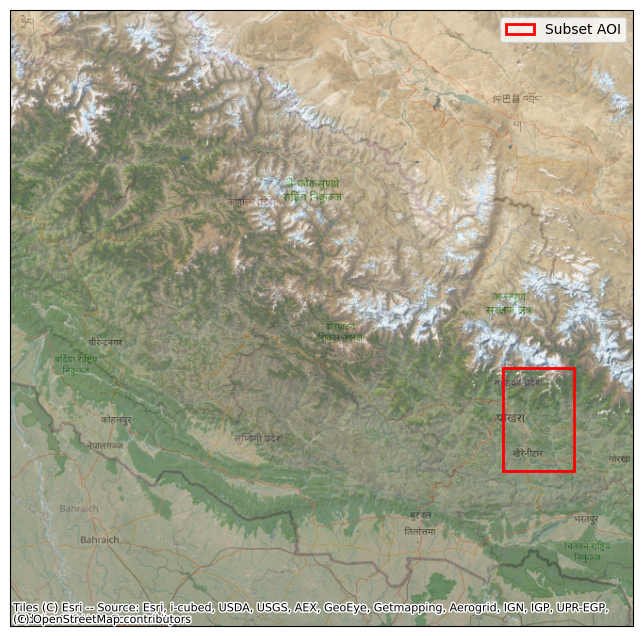

In [10]:
import cartopy.crs as ccrs
import contextily as ctx
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig = plt.figure(figsize=(10,8))     

ax = fig.add_subplot(1, 1, 1, projection=ccrs.epsg(3857))

minx, miny, maxx, maxy = hhhh[0].rio.transform_bounds("EPSG:3857", densify_pts=21)
ax.set_extent(
    [minx, maxx, miny, maxy],
    crs=ccrs.epsg(3857))


ctx.add_basemap(ax, crs="EPSG:3857", source=ctx.providers.Esri.WorldImagery)
ctx.add_basemap(ax, crs="EPSG:3857", source=ctx.providers.OpenStreetMap.Mapnik, alpha=0.5)

sub_minx, sub_miny, sub_maxx, sub_maxy = hhhh_subset[0].rio.transform_bounds("EPSG:3857", densify_pts=21)
rect = patches.Rectangle(
    (sub_minx, sub_miny),
    sub_maxx - sub_minx,
    sub_maxy - sub_miny, 
    linewidth=2, 
    edgecolor="red", 
    facecolor="none",
    label="Subset AOI",
    transform=ccrs.epsg(3857)
)
ax.add_patch(rect)

ax.legend(handles=[rect])
plt.show()

<hr>

(gcov-ts-save)=
## 4. Save the time series as a local Zarr Store

Up to this point, you have lazily loaded the time series data into xarray data structures. These hold only pointers to data stored remotely in an S3 Bucket. Accessing the values in a large dataset from S3 in Earthdata can be very slow. If you are not careful in how you work with the them, you may access the same data multiple times, slowing your work even more. Additionally, Earthdata S3 Bucket credentials expire after one hour, so if you don't complete your work within that time, you may have to repeat many slow steps in your analysis.

**To mitigate these pain points, you can save your subset time series to a Zarr Store on your local volume.**
- Local data access is much faster than remote S3 access.
  - It is still wise to avoid recomputing values via careful use of xarray.
- If you set down your work for the day or restart your notebook kernel or JupyterHub server, you can quickly reload your locally stored data.
- You are no longer time-constrained by short-lived Earthdata S3 Bucket credentials. 

### 4a. Create directories to hold the time series data and output plots

In [11]:
from pathlib import Path

time_series_example_dir = Path.home() / "NISAR_GCOV_time_series_example"

data_dir = time_series_example_dir / "data"
data_dir.mkdir(parents=True, exist_ok=True)

plot_dir = time_series_example_dir / "plots"
plot_dir.mkdir(exist_ok=True)

### 4b. Save the time series as a Zarr Store

Until now, we have not accessed any values in our xarray data structures; we have manipulated pointers to the data. To save the data to a Zarr Store, all values in the subset must be accessed, which is slow over the network. 

This is the most time consuming step in the notebook. For the 5784 x 3909 pixel subset, it takes a little under 1 minute per image.

In [12]:
%%time

# The final chunks in each dimension must not be larger than the previous chunks when saving to Zarr.
# In this example, after spatially subsetting, the final yCoordinates chunk is larger than the previous chunk.
# We must rechunk to allow us to successfully export a Zarr Store.
ts = ts.chunk({"time": 1, "yCoordinates": 2048, "xCoordinates": 2048})

zarr_ts_path = data_dir / "pokhara_timeseries.zarr"
ts.to_zarr(data_dir / "pokhara_timeseries.zarr", mode="w")

CPU times: user 56.1 s, sys: 27.5 s, total: 1min 23s
Wall time: 4min 12s


### 4c. Close the open files to the data in S3

In [13]:
for f in files:
    f.close()

<hr>

(gcov-ts-load-from-zarr)=
## 5. Load the time series from the local Zarr Store

If you have previously run Steps 1-4 of this notebook and saved a local Zarr Store, you can rerun it from this step.

### 5a. Load the Zarr Store

In [14]:
%%time

from pathlib import Path
import xarray as xr

time_series_example_dir = Path.home() / "time_series_example"
data_dir = time_series_example_dir / "data"
plot_dir = time_series_example_dir / "plots"
zarr_ts_path = data_dir / "pokhara_timeseries.zarr"

ts = xr.open_zarr(zarr_ts_path)
ts

CPU times: user 4.44 ms, sys: 2.16 ms, total: 6.6 ms
Wall time: 8.44 ms


<xarray.Dataset> Size: 452MB
Dimensions:       (time: 5, yCoordinates: 5784, xCoordinates: 3909)
Coordinates:
  * time          (time) datetime64[ns] 40B 2025-11-23T23:47:39 ... 2026-01-1...
  * yCoordinates  (yCoordinates) float64 46kB 3.152e+06 3.152e+06 ... 3.094e+06
  * xCoordinates  (xCoordinates) float64 31kB 7.902e+05 7.902e+05 ... 8.293e+05
Data variables:
    HHHH          (time, yCoordinates, xCoordinates) float32 452MB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    projection    int64 8B ...

<hr>


(gcov-ts-convert-scale)=
## 6. Data Conversion between dB and Power Scales

Focused SAR image data may come in uncalibrated digital numbers (DN) and need to be calibrated to correspond to proper radar cross section information. However, NISAR data is already radiometrically calibrated and has a scaling factor of 1.0, so we do not need to worry about this. 

The data at hand are radiometrically terrain corrected images, which are expressed as terrain flattened $\gamma^0$ backscatter coefficients. For forest and land cover monitoring applications $\gamma^o$ is the preferred metric.

We often visualize backscatter in log scale (dB), as plotting in a linear (Power) scale may obscure subtleties. However, we must compute statistics in linear scale, so you may have need to convert back and forth between Power and dB.

NISAR GCOV data are provided in Power scale.

### 6a. Convert the `HHHH` data from power to dB

To convert from power to dB, apply: $\gamma^o_{dB} = 10 {\log_{10}(\gamma^o_{power})}$

In [15]:
%%time
import numpy as np

ts_db = db = 10 * np.log10(ts.HHHH.where(ts.HHHH > 0)) # avoid log10 on values <= 0 to avoid division by zero warnings

# load ts_db values into memory once now to avoid multiple loads in subsequent code cells
ts_db.load()
ts_db

CPU times: user 1.42 s, sys: 405 ms, total: 1.82 s
Wall time: 1.86 s


<xarray.DataArray 'HHHH' (time: 5, yCoordinates: 5784, xCoordinates: 3909)> Size: 452MB
array([[[-1.2319717e+00, -8.0920947e-01, -2.3557777e+00, ...,
         -1.4072173e+02, -1.4092639e+02, -1.4319055e+02],
        [-1.0060458e+01, -2.3483174e+00,  4.4914908e+00, ...,
         -1.4125180e+02, -1.4273424e+02, -1.4109274e+02],
        [-1.1114291e+01, -6.1633768e+00,  2.4085901e+00, ...,
         -1.4041583e+02, -1.4236179e+02, -1.4576730e+02],
        ...,
        [-5.3822947e+00, -6.6673751e+00, -9.2022591e+00, ...,
         -5.6725717e+00, -8.2221231e+00, -6.6253557e+00],
        [ 2.8323867e+00, -6.4717293e+00, -5.2007799e+00, ...,
         -8.5405140e+00, -5.2946806e+00, -4.1965313e+00],
        [ 3.5443859e+00, -1.8782542e+00, -4.0742640e+00, ...,
         -6.4944701e+00, -2.5781937e+00, -6.0418911e+00]],

       [[-4.5079079e+00,  7.8610969e-01, -9.2913449e-01, ...,
         -1.4384598e+02, -1.4198540e+02, -1.4073938e+02],
        [-1.0643786e+01, -2.2427540e+00,  3.6886387e+00, ...,
         -1.4320767e+02, -1.4192488e+02, -1.3902879e+02],
        [-9.5655766e+00, -4.9741554e+00,  2.2452567e+00, ...,
         -1.4221693e+02, -1.4123799e+02, -1.3941539e+02],
...
         -8.9081984e+00, -6.5870218e+00, -7.8412313e+00],
        [ 3.3320711e+00, -5.8205757e+00, -7.3734388e+00, ...,
         -9.7497969e+00, -5.4760957e+00, -4.3448091e+00],
        [ 6.0085192e-02,  2.6690122e-02, -2.1596990e+00, ...,
         -6.2273288e+00, -5.6439791e+00, -4.4420786e+00]],

       [[-3.4950485e+00,  1.0069461e+00,  4.3300626e-01, ...,
         -1.4467700e+02, -1.4249396e+02, -1.4094463e+02],
        [-7.6601315e+00, -6.3574848e+00, -2.6045499e+00, ...,
         -1.4254239e+02, -1.4077249e+02, -1.4392587e+02],
        [-1.1494299e+01, -1.5155008e+01, -3.3806496e+00, ...,
         -1.4059050e+02, -1.4083705e+02, -1.4297339e+02],
        ...,
        [-5.4433069e+00, -9.7364454e+00, -8.2407007e+00, ...,
         -7.9407735e+00, -6.5684133e+00, -7.1887560e+00],
        [ 2.9748347e+00, -4.9877172e+00, -6.2072206e+00, ...,
         -9.3038769e+00, -6.0547962e+00, -6.5718727e+00],
        [ 3.0132148e+00,  1.4762574e-01, -3.3653049e+00, ...,
         -4.9452953e+00, -3.8165963e+00, -5.4411607e+00]]],
      shape=(5, 5784, 3909), dtype=float32)
Coordinates:
  * time          (time) datetime64[ns] 40B 2025-11-23T23:47:39 ... 2026-01-1...
  * yCoordinates  (yCoordinates) float64 46kB 3.152e+06 3.152e+06 ... 3.094e+06
  * xCoordinates  (xCoordinates) float64 31kB 7.902e+05 7.902e+05 ... 8.293e+05
Attributes:
    description:    Covariance between HH and HH
    grid_mapping:   projection
    long_name:      Geocoded polarimetric covariance term HHHH
    max_value:      271468.03125
    mean_value:     0.777672529220581
    min_value:      4.061232434894211e-19
    sample_stddev:  75.61554718017578
    units:          1
    valid_min:      0.0

### 6b. Plot the histogram of the dB data and confirm a normal distribution

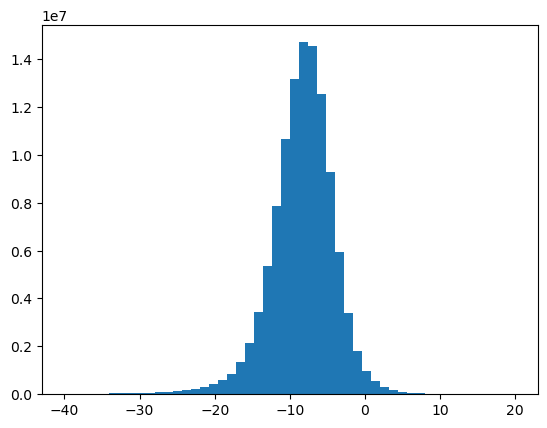

In [16]:
ax = ts_db.values.ravel()
ax = ax[(ax < 20) & (ax > -40)]
plt.hist(ax, bins=50)
plt.show()

## 6c. Convert from dB back to power

While dB-scaled images are often visually pleasing, they are not a good basis for mathematical operations. For instance, when computing the mean backscatter, we cannot simply average data in log scale. 
    
Please note that the correct scale in which operations need to be performed is the power scale. This is critical, e.g. when speckle filters are applied, when spatial operations like block averaging are performed, or other statistics across time series are analyzed.

To convert from dB to power, apply: $\gamma^o_{pwr} = 10^{\frac{\gamma^o_{dB}}{10}}$

In [17]:
ts_pwr = np.power(10.0, ts_db/10.0)
ts_pwr

<xarray.DataArray 'HHHH' (time: 5, yCoordinates: 5784, xCoordinates: 3909)> Size: 452MB
array([[[7.53013611e-01, 8.30001831e-01, 5.81329286e-01, ...,
         8.46891577e-15, 8.07906378e-15, 4.79672090e-15],
        [9.86175463e-02, 5.82328796e-01, 2.81286621e+00, ...,
         7.49583077e-15, 5.32814259e-15, 7.77546007e-15],
        [7.73696974e-02, 2.41914749e-01, 1.74124146e+00, ...,
         9.08692457e-15, 5.80525889e-15, 2.65014269e-15],
        ...,
        [2.89581329e-01, 2.15408340e-01, 1.20163918e-01, ...,
         2.70858735e-01, 1.50587067e-01, 2.17502594e-01],
        [1.91972351e+00, 2.25334182e-01, 3.01940948e-01, ...,
         1.39942169e-01, 2.95482606e-01, 3.80493194e-01],
        [2.26171875e+00, 6.48895264e-01, 3.91357422e-01, ...,
         2.24157348e-01, 5.52307129e-01, 2.48777390e-01]],

       [[3.54167908e-01, 1.19842529e+00, 8.07395935e-01, ...,
         4.12479380e-15, 6.33082420e-15, 8.43454402e-15],
        [8.62226561e-02, 5.96656799e-01, 2.33810425e+00, ...,
         4.77785112e-15, 6.41966398e-15, 1.25060535e-14],
        [1.10520378e-01, 3.18115234e-01, 1.67697144e+00, ...,
         6.00215170e-15, 7.51970270e-15, 1.14409265e-14],
...
         1.28581986e-01, 2.19430909e-01, 1.64390564e-01],
        [2.15380859e+00, 2.61783570e-01, 1.83086410e-01, ...,
         1.05930321e-01, 2.83393860e-01, 3.67721558e-01],
        [1.01393127e+00, 1.00616455e+00, 6.08177185e-01, ...,
         2.38378525e-01, 2.72647858e-01, 3.59577209e-01]],

       [[4.47193146e-01, 1.26094055e+00, 1.10484314e+00, ...,
         3.40643405e-15, 5.63124783e-15, 8.04521380e-15],
        [1.71390548e-01, 2.31340408e-01, 5.48965454e-01, ...,
         5.56879101e-15, 8.37048208e-15, 4.04960184e-15],
        [7.08875656e-02, 3.05140056e-02, 4.59129333e-01, ...,
         8.72871687e-15, 8.24698213e-15, 5.04268106e-15],
        ...,
        [2.85541534e-01, 1.06256485e-01, 1.49944276e-01, ...,
         1.60665512e-01, 2.20373139e-01, 1.91040039e-01],
        [1.98373413e+00, 3.17123383e-01, 2.39484802e-01, ...,
         1.17384925e-01, 2.48039246e-01, 2.20197663e-01],
        [2.00134277e+00, 1.03457642e+00, 4.60754395e-01, ...,
         3.20236236e-01, 4.15279388e-01, 2.85682678e-01]]],
      shape=(5, 5784, 3909), dtype=float32)
Coordinates:
  * time          (time) datetime64[ns] 40B 2025-11-23T23:47:39 ... 2026-01-1...
  * yCoordinates  (yCoordinates) float64 46kB 3.152e+06 3.152e+06 ... 3.094e+06
  * xCoordinates  (xCoordinates) float64 31kB 7.902e+05 7.902e+05 ... 8.293e+05
Attributes:
    description:    Covariance between HH and HH
    grid_mapping:   projection
    long_name:      Geocoded polarimetric covariance term HHHH
    max_value:      271468.03125
    mean_value:     0.777672529220581
    min_value:      4.061232434894211e-19
    sample_stddev:  75.61554718017578
    units:          1
    valid_min:      0.0

## Plot the histogram of the Power-scale data

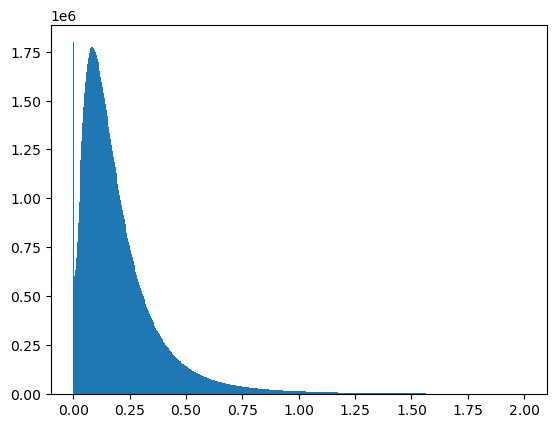

In [18]:
ax = ts_pwr.values.ravel()
ax = ax[ax < 2]
plt.hist(ax, bins=500)
plt.show()

<hr>

(gcov-ts-animate)=
## 7. SAR Time Series Animation

This section introduces you to the handling and analysis of SAR time series stacks. A focus will be put on time series visualizations, which allow us to inspect time series in more depth. 

Animations will display interactively and be saved as gifs.

### 7a. Create a Time Series Animation from the dB Subset

In [19]:
%%capture
from matplotlib.animation import FuncAnimation
from matplotlib.animation import FFMpegWriter, PillowWriter

vmin = ts_db.quantile(0.05, skipna=True).values.item()
vmax = ts_db.quantile(0.95, skipna=True).values.item()

fig, ax = plt.subplots(figsize=(6, 6), )
frame_0 = ts_db.isel(time=0).values
im = ax.imshow(frame_0, vmin=vmin, vmax=vmax, origin="upper", cmap="grey")
cb = fig.colorbar(im, ax=ax, label="γ⁰ (dB)")
ax.set_title(np.datetime_as_string(ts_db.time.values[0], unit='s'))
ax.set_axis_off()

def animate(i):
    frame = ts_db.isel(time=i).values
    im.set_data(frame)
    ax.set_title(np.datetime_as_string(ts_db.time.values[i], unit='s'))
    return (im,)

ani = FuncAnimation(fig, animate, frames=ts_db.sizes["time"], interval=300, blit=False)

plt.show()

### 7b. Create a javascript animation of the time-series running inline in the notebook:

In [20]:
from IPython.display import HTML

HTML(ani.to_jshtml())

### 7c. Save the animation (animation.gif):

In [21]:
ani.save(plot_dir / "timeseries_animation.gif", writer=PillowWriter(fps=3))

<hr>

(gcov-ts-means)=
## 8. Calculate the Time Series of Means

Calculate the Time Series of Means Across the HHHH

To create the time series of means:
1. Compute subset means for each time-step using data in power scale ($\gamma^o_{pwr}$) .
1. Convert the resulting mean values into dB scale for visualization.

### 8a. Identify the axis on which to take the means

Note that the Dataset dimensions are ('time', 'yCoordinates', 'xCoordinates')

In [22]:
ts_pwr.dims

('time', 'yCoordinates', 'xCoordinates')

### 8b. Compute the means in power scale:

Since we want to take the means across the spatial dimensions (dims 1 and 2) on each day, we should pass `axis=(1, 2)` to `np.mean`.

This will compute the backscatter means spatially, while leaving the time dimension in place.

In [23]:
means_pwr = np.mean(ts_pwr, axis=(1, 2))
means_pwr

<xarray.DataArray 'HHHH' (time: 5)> Size: 20B
array([0.4241392 , 0.41252065, 0.4040923 , 0.3896399 , 0.35938358],
      dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 40B 2025-11-23T23:47:39 ... 2026-01-10T23:...
Attributes:
    description:    Covariance between HH and HH
    grid_mapping:   projection
    long_name:      Geocoded polarimetric covariance term HHHH
    max_value:      271468.03125
    mean_value:     0.777672529220581
    min_value:      4.061232434894211e-19
    sample_stddev:  75.61554718017578
    units:          1
    valid_min:      0.0

### 8c. Convert the resulting mean value time-series to dB scale for visualization

In [24]:
means_db = 10 * np.log10(means_pwr.where(means_pwr > 0))
means_db

<xarray.DataArray 'HHHH' (time: 5)> Size: 20B
array([-3.724916 , -3.8455434, -3.935194 , -4.0933657, -4.4444175],
      dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 40B 2025-11-23T23:47:39 ... 2026-01-10T23:...
Attributes:
    description:    Covariance between HH and HH
    grid_mapping:   projection
    long_name:      Geocoded polarimetric covariance term HHHH
    max_value:      271468.03125
    mean_value:     0.777672529220581
    min_value:      4.061232434894211e-19
    sample_stddev:  75.61554718017578
    units:          1
    valid_min:      0.0

### 8d. Plot the time series of means

Plot both the Power and dB time series of means

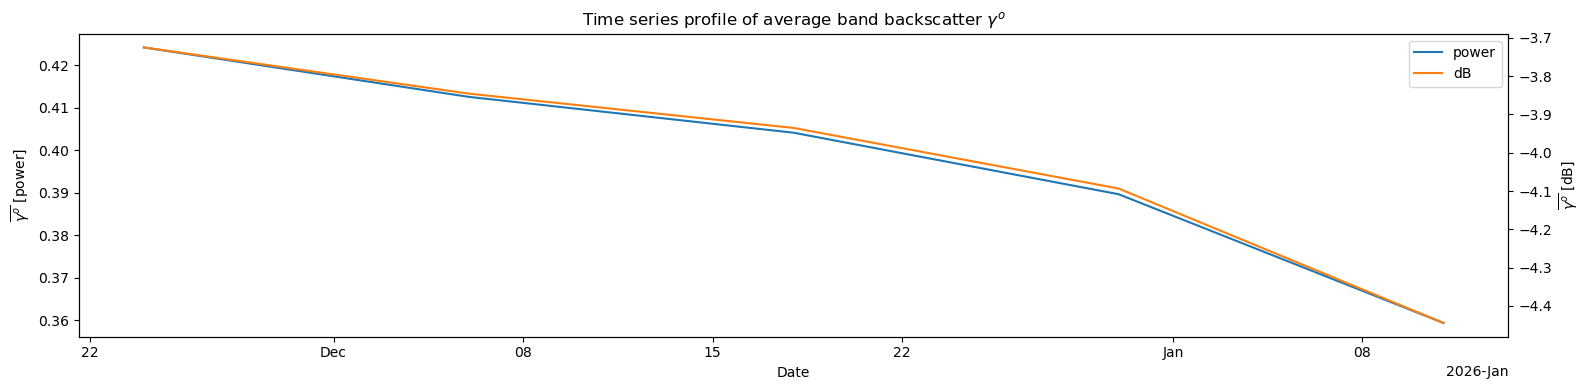

In [25]:
import matplotlib.dates as mdates

fig, ax1 = plt.subplots(figsize=(16, 4))

# left y-axis: power
means_pwr.plot.line(ax=ax1, x="time", label="power")
ax1.set_xlabel("Date")
ax1.set_ylabel(r"$\overline{\gamma^o}$ [power]")

# right y-axis: dB
ax2 = ax1.twinx()
means_db.plot.line(ax=ax2, x='time', color='tab:orange', label='dB')
ax2.set_ylabel(r'$\overline{\gamma^o}$ [dB]')

ax2.set_xlim(ax1.get_xlim())
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper right')

ax1.set_title(r'Time series profile of average band backscatter $\gamma^o$')
ax2.set_title("")
plt.tight_layout()
plt.show()


### 8e. Create Two-Panel Figure, Animating Both the Imagery and the Daily Global Means $\mu_{\gamma^0_{dB}}$

In [26]:
%%capture
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as an
import matplotlib.dates as mdates

vmin = ts_db.quantile(0.05, skipna=True).values.item()
vmax = ts_db.quantile(0.95, skipna=True).values.item()

t_num = mdates.date2num(ts_db.time.values)                    
means = np.asarray(means_db.compute().values).reshape(-1)

fig = plt.figure(figsize=(12,4))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

# Image axis
frame_0 = ts_db.isel(time=0).values
im = ax1.imshow(frame_0, vmin=vmin, vmax=vmax, origin="upper", cmap="grey")
ax1.set_title(np.datetime_as_string(ts_db.time.values[0], unit='D'))
ax1.set_axis_off()

# Line axis
(l,) = ax2.plot([], [], lw=3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax2.set_xlim(t_num.min(), t_num.max())

ax2.set_ylim(np.nanmin(means)-0.5, np.nanmax(means)+0.5)
ax2.set_ylabel(r"Backscatter Means $\mu_{\gamma^0_{dB}}$")
ax2.set_title(str(ts_db.time.values[0].astype("datetime64[D]")))

def init():
    l.set_data([], [])
    return im, l

def animate(i):
    ts = str(ts_db.time.values[i].astype("datetime64[D]"))
    ax1.set_title(ts)
    ax2.set_title(ts)

    im.set_data(ts_db.isel(time=i).values)
    l.set_data(t_num[:i+1], means[:i+1])

    return im, l

ani = an.FuncAnimation(fig, animate, frames=len(ts_db.time), init_func=init, interval=400, blit=False)
plt.tight_layout()
plt.show()

### 8f. Create a javascript animation of the time-series running inline in the notebook:

In [27]:
HTML(ani.to_jshtml())

### Save the animated time-series and histogram (animation_histogram.gif):

In [28]:
ani.save(plot_dir / 'animation_histogram.gif', writer='pillow', fps=2)

<hr>

(gcov-ts-summary)=
## 9. Summary
**Having completed this workflow, you have:**
- Searched and downloaded a NISAR GCOV time series
- Subset the data to a specific polarization and AOI
- Converted the data between linear and logarithmic scales
- Generated a backscatter time series animation and output it as a gif
- Calculated the time series of means, animated it, and output it as a gif

<hr>

(gcov-ts-resources)=
## 10. Resources and references
 - [NISAR Data User Guide](https://nisar-docs.asf.alaska.edu/)
 - [UAF GEOS657 Microwave Remote Sensing class website](https://radar.community.uaf.edu/)
 - **Authors:**
   - Alex Lewandowski; [Alaska Satellite Facility](https://asf.alaska.edu/)
   - Adapted for NISAR data from [earlier work](https://github.com/ASFOpenSARlab/opensarlab-notebooks/blob/master/SAR_Training/English/Master/Time_Series_Example.ipynb) by: 
     -  Franz J Meyer; [University of Alaska Fairbanks](https://www.uaf.edu/uaf/)
     -  Josef Kellndorfer, [Earth Big Data, LLC](http://earthbigdata.com/)
